# v5: DenseNet v3a — Post-hoc 閾値最適化・二値集約

**前提:**
- `results/models/v3a_val_predictions.npz` （raw logits + raw probs）
- `results/models/v3a_test_predictions.npz` （raw logits + raw probs）
- `results/v4_TS/temperature_v3a.json` （v4で最適化したT）

**処理順序:**
1. val/test npz + T ロード → その場でTS適用（npzは書き換えない）
2. A-6: 閾値最適化（7クラス OvR）— **valのみで最適化**
3. A-7: 良悪性の二値集約 + ROC曲線 — **valのみで最適化**
4. A-8: 比較表
5. **test上で最終メトリクスを報告**（一切の最適化に使わない）

**原則:** 閾値はvalで決定、testは最終報告のみ。npzは常にraw。


### ライブラリ読み込み・出力先設定

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import json as _json
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim

NB_NAME     = 'v3a'
RESULTS_DIR = Path('../results/v5_ph')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Results dir: {RESULTS_DIR.resolve()}')

CLASS_NAMES       = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
NUM_CLASSES       = len(CLASS_NAMES)
MEL_IDX           = CLASS_NAMES.index('mel')
MALIGNANT_INDICES = [CLASS_NAMES.index(c) for c in ['mel', 'bcc', 'akiec']]
BENIGN_INDICES    = [CLASS_NAMES.index(c) for c in ['nv', 'bkl', 'df', 'vasc']]


Results dir: /home/komai/skin-lesion-triage/results/v5_ph


## 1. val predictions ロード

In [2]:
NPZ_PATH = Path('../results/models/v3a_val_predictions.npz')
_data         = np.load(NPZ_PATH)
all_probs_raw = _data['all_probs']   # (N, 7) TS前の生probs
all_logits_np = _data['all_logits']  # (N, 7) TS最適化の入力
y_true        = _data['y_true']      # (N,)
y_true_onehot = np.eye(NUM_CLASSES)[y_true]
N             = len(y_true)

print(f'Loaded: {NPZ_PATH}')
print(f'Val samples: {N}')
print(f'Class dist:  {dict(zip(CLASS_NAMES, np.bincount(y_true, minlength=NUM_CLASSES)))}')


Loaded: ../results/models/v3a_val_predictions.npz
Val samples: 551
Class dist:  {'akiec': np.int64(15), 'bcc': np.int64(17), 'bkl': np.int64(44), 'df': np.int64(4), 'mel': np.int64(23), 'nv': np.int64(441), 'vasc': np.int64(7)}


## 2. Temperature Scaling（v4から読み込み）

TSの最適化はv4で実施済み。ここではv4で算出したTを読み込み、
val/test logitsにその場でTS適用する（npzは書き換えない）。


In [3]:
# ============================================================
# Calibration 関数定義（ECE計算 + TS適用のみ。TS最適化はv4の責務）
# ============================================================
import json

def compute_ece(probs, labels, n_bins=15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies  = (predictions == labels).astype(float)
    bin_edges  = np.linspace(0.0, 1.0, n_bins + 1)
    bin_accs   = np.zeros(n_bins)
    bin_confs  = np.zeros(n_bins)
    bin_counts = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidences >= lo) & (confidences <= hi if i == n_bins - 1 else confidences < hi)
        bin_counts[i] = mask.sum()
        if bin_counts[i] > 0:
            bin_accs[i]  = accuracies[mask].mean()
            bin_confs[i] = confidences[mask].mean()
    ece = np.sum(bin_counts / len(labels) * np.abs(bin_accs - bin_confs))
    return ece, {'bin_edges': bin_edges, 'bin_accs': bin_accs,
                 'bin_confs': bin_confs, 'bin_counts': bin_counts}

def compute_classwise_ece(probs, labels, class_idx, n_bins=15):
    class_probs = probs[:, class_idx]
    class_true  = (labels == class_idx).astype(float)
    bin_edges  = np.linspace(0.0, 1.0, n_bins + 1)
    bin_accs   = np.zeros(n_bins)
    bin_confs  = np.zeros(n_bins)
    bin_counts = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (class_probs >= lo) & (class_probs <= hi if i == n_bins - 1 else class_probs < hi)
        bin_counts[i] = mask.sum()
        if bin_counts[i] > 0:
            bin_accs[i]  = class_true[mask].mean()
            bin_confs[i] = class_probs[mask].mean()
    ece = np.sum(bin_counts / len(labels) * np.abs(bin_accs - bin_confs))
    return ece, {'bin_edges': bin_edges, 'bin_accs': bin_accs,
                 'bin_confs': bin_confs, 'bin_counts': bin_counts}

def apply_temperature(logits_np, T):
    scaled = torch.from_numpy(logits_np).float() / T
    return torch.softmax(scaled, dim=1).numpy()

print("Calibration functions defined ✓")


Calibration functions defined ✓


In [4]:
# ============================================================
# v4からTをロードし、val logitsにその場でTS適用（npzは書き換えない）
# ============================================================
T_JSON_PATH = Path('../results/v4_TS/temperature_v3a.json')
with open(T_JSON_PATH) as f:
    t_data = _json.load(f)
T = t_data['temperature']
print(f'Loaded T = {T:.4f} from {T_JSON_PATH}')

# val logitsにTS適用（メモリ上のみ）
all_probs = apply_temperature(all_logits_np, T)
y_true_onehot = np.eye(NUM_CLASSES)[y_true]
N = len(y_true)

# ECE確認（val）
ece_before, _ = compute_ece(all_probs_raw, y_true)
ece_after, _  = compute_ece(all_probs, y_true)
print(f'Val ECE: {ece_before:.4f} → {ece_after:.4f} (Δ={ece_after-ece_before:+.4f})')
print('all_probs → TS補正済み（メモリ上のみ、npz未変更） ✓')


Loaded T = 1.4478 from ../results/v4_TS/temperature_v3a.json
Val ECE: 0.0316 → 0.0289 (Δ=-0.0026)
all_probs → TS補正済み（メモリ上のみ、npz未変更） ✓


## 3. Post-hoc 閾値最適化・二値集約

以降は TS補正済みの `all_probs` を使用。
閾値最適化 → 二値集約の順序で実行。


In [5]:
import pandas as pd
from sklearn.metrics import (
    roc_curve, auc, classification_report,
    confusion_matrix, precision_recall_fscore_support, roc_auc_score
)
NB_NAME = 'v3a'


### A-6 — 閾値最適化（7クラス OvR）

A-6: Per-class OvR Threshold Optimization


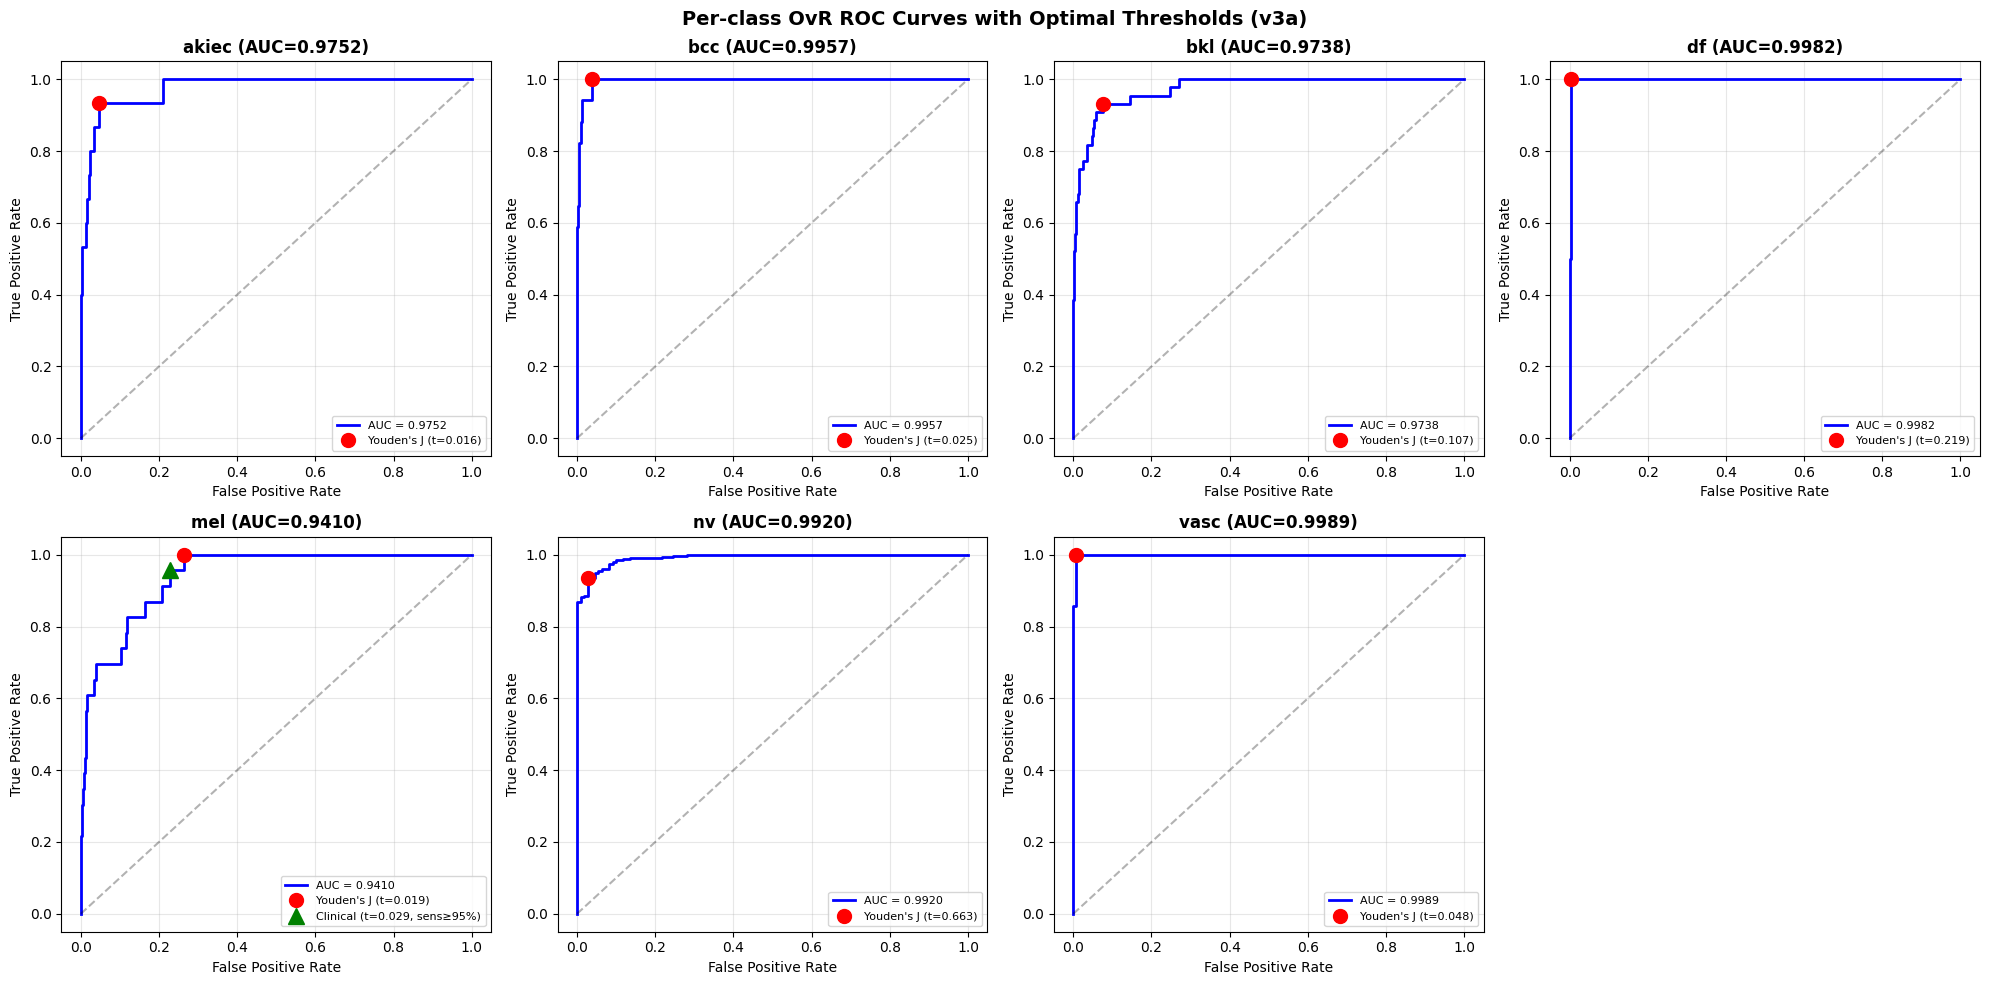


--- Youden's J Optimal Thresholds (all 7 classes) ---
Class     Threshold  Sensitivity  Specificity   Youden J
-------------------------------------------------------
akiec        0.0161       0.9333       0.9534     0.8867
bcc          0.0252       1.0000       0.9625     0.9625
bkl          0.1066       0.9318       0.9231     0.8549
df           0.2188       1.0000       0.9963     0.9963
mel          0.0194       1.0000       0.7367     0.7367 ← mel
nv           0.6629       0.9342       0.9727     0.9070
vasc         0.0483       1.0000       0.9926     0.9926

--- Clinical Threshold (mel sensitivity >= 95%) ---
mel          0.0292       0.9565       0.7708

→ 統計的最適(Youden): mel閾値 = 0.0194 (感度 100.00%)
→ 臨床的最適(≧95%):  mel閾値 = 0.0292 (感度 95.65%)
→ 「統計的最適と臨床的最適は異なる。どちらを選ぶかは運用コンテキスト次第」

--- Classification Report: Youden's J Threshold ---
(Fallback to argmax: 0/551 samples)
              precision    recall  f1-score   support

       akiec      0.667     0.533     0.593        15
  

In [6]:
# ============================================================
# Cell 2: A-6 — 閾値最適化（7クラス OvR）
# ============================================================
"""
A-6: 各クラスのOvR ROC曲線から2種類の閾値を算出
  - 統計的最適閾値: Youden's J = sensitivity + specificity - 1 を最大化
  - 臨床的最適閾値: mel感度≧95%を満たす最大特異度の閾値
"""

print("=" * 70)
print("A-6: Per-class OvR Threshold Optimization")
print("=" * 70)

# --- 6-a: 全7クラスの OvR ROC + Youden's J ---
thresholds_youden = {}
thresholds_clinical = {}
roc_data = {}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, cls_name in enumerate(CLASS_NAMES):
    fpr, tpr, thresholds = roc_curve(y_true_onehot[:, i], all_probs[:, i])
    roc_auc_val = auc(fpr, tpr)
    roc_data[cls_name] = {'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds, 'auc': roc_auc_val}

    # Youden's J
    j_scores = tpr - fpr
    best_j_idx = j_scores.argmax()
    best_threshold = thresholds[best_j_idx]
    best_sensitivity = tpr[best_j_idx]
    best_specificity = 1 - fpr[best_j_idx]
    thresholds_youden[cls_name] = {
        'threshold': best_threshold,
        'sensitivity': best_sensitivity,
        'specificity': best_specificity,
        'youden_j': j_scores[best_j_idx]
    }

    # 臨床的閾値（mel感度≧95%）— melクラスのみ
    if cls_name == 'mel':
        clinical_candidates = np.where(tpr >= 0.95)[0]
        if len(clinical_candidates) > 0:
            # tpr≧95%を満たす中で最も特異度が高い（fprが最小の）閾値
            # tprは昇順なので、候補の最後（最も閾値が低い≒感度が高い側）ではなく
            # fprが最小のものを選ぶ
            best_clinical_idx = clinical_candidates[np.argmin(fpr[clinical_candidates])]
            clinical_threshold = thresholds[best_clinical_idx]
            clinical_sensitivity = tpr[best_clinical_idx]
            clinical_specificity = 1 - fpr[best_clinical_idx]
        else:
            # 95%を達成できない場合
            clinical_threshold = 0.0
            clinical_sensitivity = 1.0
            clinical_specificity = 0.0
            print("  WARNING: mel sensitivity >= 95% not achievable!")

        thresholds_clinical['mel'] = {
            'threshold': clinical_threshold,
            'sensitivity': clinical_sensitivity,
            'specificity': clinical_specificity
        }

    # プロット
    ax = axes[i]
    ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {roc_auc_val:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)

    # Youden's J点
    ax.plot(fpr[best_j_idx], tpr[best_j_idx], 'ro', markersize=10,
            label=f"Youden's J (t={best_threshold:.3f})")

    # mel臨床閾値
    if cls_name == 'mel' and len(clinical_candidates) > 0:
        ax.plot(fpr[best_clinical_idx], tpr[best_clinical_idx], 'g^', markersize=12,
                label=f'Clinical (t={clinical_threshold:.3f}, sens≥95%)')

    ax.set_title(f'{cls_name} (AUC={roc_auc_val:.4f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

# 空のサブプロットを非表示
axes[7].axis('off')

plt.suptitle(f"Per-class OvR ROC Curves with Optimal Thresholds ({NB_NAME})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_a6_ovr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 6-b: 閾値サマリーテーブル ---
print("\n--- Youden's J Optimal Thresholds (all 7 classes) ---")
print(f"{'Class':<8} {'Threshold':>10} {'Sensitivity':>12} {'Specificity':>12} {'Youden J':>10}")
print("-" * 55)
for cls_name in CLASS_NAMES:
    t = thresholds_youden[cls_name]
    marker = " ← mel" if cls_name == 'mel' else ""
    print(f"{cls_name:<8} {t['threshold']:>10.4f} {t['sensitivity']:>12.4f} {t['specificity']:>12.4f} {t['youden_j']:>10.4f}{marker}")

print(f"\n--- Clinical Threshold (mel sensitivity >= 95%) ---")
tc = thresholds_clinical['mel']
print(f"mel      {tc['threshold']:>10.4f} {tc['sensitivity']:>12.4f} {tc['specificity']:>12.4f}")
print(f"\n→ 統計的最適(Youden): mel閾値 = {thresholds_youden['mel']['threshold']:.4f} (感度 {thresholds_youden['mel']['sensitivity']:.2%})")
print(f"→ 臨床的最適(≧95%):  mel閾値 = {thresholds_clinical['mel']['threshold']:.4f} (感度 {thresholds_clinical['mel']['sensitivity']:.2%})")
print(f"→ 「統計的最適と臨床的最適は異なる。どちらを選ぶかは運用コンテキスト次第」")


# --- 6-c: 閾値ベースの多クラス予測関数 ---
def predict_with_thresholds(probs, thresholds_dict, class_names):
    """
    閾値ベースの予測。各クラスのOvR閾値を超えた中で最も確率が高いクラスを選択。
    どのクラスも閾値を超えない場合はargmaxにフォールバック。

    Parameters:
        probs: (N, C) softmax確率
        thresholds_dict: {class_name: {'threshold': float, ...}}
        class_names: クラス名リスト

    Returns:
        predictions: (N,) 予測ラベル
        n_fallback: argmaxにフォールバックした件数
    """
    N, C = probs.shape
    predictions = np.zeros(N, dtype=int)
    n_fallback = 0

    thresholds_array = np.array([thresholds_dict[c]['threshold'] for c in class_names])

    for idx in range(N):
        p = probs[idx]
        above_threshold = p >= thresholds_array
        if above_threshold.any():
            # 閾値を超えたクラスの中で最大確率
            masked = np.where(above_threshold, p, -1)
            predictions[idx] = masked.argmax()
        else:
            # フォールバック
            predictions[idx] = p.argmax()
            n_fallback += 1

    return predictions, n_fallback


# Youden閾値で予測
y_pred_youden, n_fb_youden = predict_with_thresholds(all_probs, thresholds_youden, CLASS_NAMES)
print(f"\n--- Classification Report: Youden's J Threshold ---")
print(f"(Fallback to argmax: {n_fb_youden}/{N} samples)")
print(classification_report(y_true, y_pred_youden, target_names=CLASS_NAMES, digits=3))

### A-7 — 良悪性の二値集約 + ROC曲線

A-7: Binary Malignant/Benign Aggregation (Esteva 2017 approach)

Binary distribution: malignant=55, benign=496
Malignant classes (mel+bcc+akiec): indices [4, 1, 0]

Binary ROC-AUC: 0.9683

Binary Youden's J:  threshold=0.1439, sensitivity=0.9636, specificity=0.8649
Binary Clinical(≧95%): threshold=0.1439, sensitivity=0.9636, specificity=0.8649


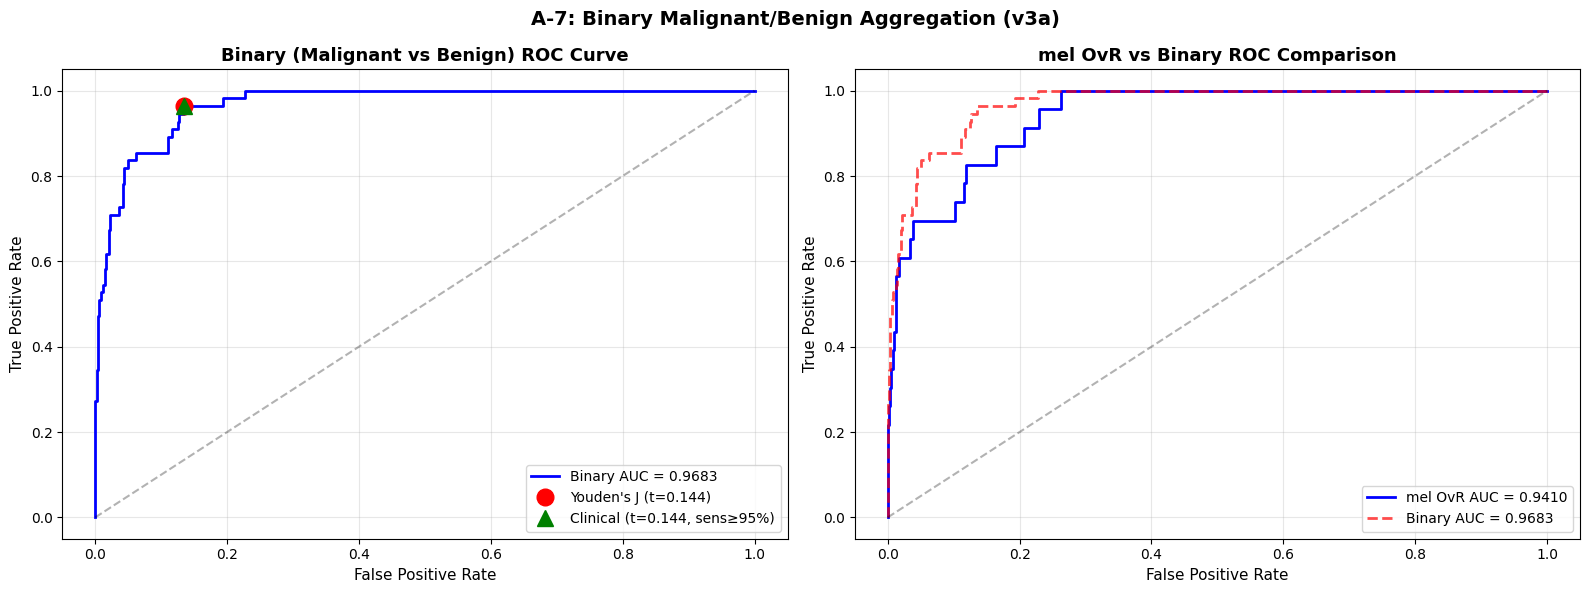


--- Binary Classification: Youden (t=0.1439) ---
              precision    recall  f1-score   support

      benign      0.995     0.865     0.926       496
   malignant      0.442     0.964     0.606        55

    accuracy                          0.875       551
   macro avg      0.719     0.914     0.766       551
weighted avg      0.940     0.875     0.894       551

--- Binary Classification: Clinical (t=0.1439, sens≥95%) ---
              precision    recall  f1-score   support

      benign      0.995     0.865     0.926       496
   malignant      0.442     0.964     0.606        55

    accuracy                          0.875       551
   macro avg      0.719     0.914     0.766       551
weighted avg      0.940     0.875     0.894       551



In [7]:
# ============================================================
# Cell 3: A-7 — 良悪性の二値集約 + ROC曲線
# ============================================================
"""
A-7: Esteva (2017) と同じアプローチ
  p_malignant = p_mel + p_bcc + p_akiec
  p_benign    = p_nv + p_bkl + p_df + p_vasc
  
  7クラスでmel→bccと間違えても、二値では「悪性」で正解。
  臨床的にも「要精査」の判断は正しい。
"""

print("=" * 70)
print("A-7: Binary Malignant/Benign Aggregation (Esteva 2017 approach)")
print("=" * 70)

# --- 7-a: 二値確率の計算 ---
p_malignant = all_probs[:, MALIGNANT_INDICES].sum(axis=1)  # (N,)
p_benign    = all_probs[:, BENIGN_INDICES].sum(axis=1)      # (N,)

# 真のラベルを二値に変換
y_true_binary = np.isin(y_true, MALIGNANT_INDICES).astype(int)  # 1=malignant, 0=benign

n_malignant = y_true_binary.sum()
n_benign = N - n_malignant
print(f"\nBinary distribution: malignant={n_malignant}, benign={n_benign}")
print(f"Malignant classes (mel+bcc+akiec): indices {MALIGNANT_INDICES}")

# --- 7-b: 二値ROC曲線 + 閾値最適化 ---
fpr_bin, tpr_bin, thresholds_bin = roc_curve(y_true_binary, p_malignant)
roc_auc_binary = auc(fpr_bin, tpr_bin)

# Youden's J（二値）
j_bin = tpr_bin - fpr_bin
best_j_bin_idx = j_bin.argmax()
binary_threshold_youden = thresholds_bin[best_j_bin_idx]
binary_sens_youden = tpr_bin[best_j_bin_idx]
binary_spec_youden = 1 - fpr_bin[best_j_bin_idx]

# 臨床閾値（二値 感度≧95%）
clinical_bin_candidates = np.where(tpr_bin >= 0.95)[0]
if len(clinical_bin_candidates) > 0:
    best_clinical_bin_idx = clinical_bin_candidates[np.argmin(fpr_bin[clinical_bin_candidates])]
    binary_threshold_clinical = thresholds_bin[best_clinical_bin_idx]
    binary_sens_clinical = tpr_bin[best_clinical_bin_idx]
    binary_spec_clinical = 1 - fpr_bin[best_clinical_bin_idx]
else:
    binary_threshold_clinical = 0.0
    binary_sens_clinical = 1.0
    binary_spec_clinical = 0.0

print(f"\nBinary ROC-AUC: {roc_auc_binary:.4f}")
print(f"\nBinary Youden's J:  threshold={binary_threshold_youden:.4f}, "
      f"sensitivity={binary_sens_youden:.4f}, specificity={binary_spec_youden:.4f}")
print(f"Binary Clinical(≧95%): threshold={binary_threshold_clinical:.4f}, "
      f"sensitivity={binary_sens_clinical:.4f}, specificity={binary_spec_clinical:.4f}")

# --- 7-c: ROC曲線プロット（二値） ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左: 二値ROC
ax = axes[0]
ax.plot(fpr_bin, tpr_bin, 'b-', linewidth=2, label=f'Binary AUC = {roc_auc_binary:.4f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.plot(fpr_bin[best_j_bin_idx], tpr_bin[best_j_bin_idx], 'ro', markersize=12,
        label=f"Youden's J (t={binary_threshold_youden:.3f})")
if len(clinical_bin_candidates) > 0:
    ax.plot(fpr_bin[best_clinical_bin_idx], tpr_bin[best_clinical_bin_idx], 'g^', markersize=12,
            label=f'Clinical (t={binary_threshold_clinical:.3f}, sens≥95%)')
ax.set_title('Binary (Malignant vs Benign) ROC Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

# 右: mel単独OvR ROC（比較用）
ax = axes[1]
mel_roc = roc_data['mel']
ax.plot(mel_roc['fpr'], mel_roc['tpr'], 'b-', linewidth=2,
        label=f"mel OvR AUC = {mel_roc['auc']:.4f}")
ax.plot(fpr_bin, tpr_bin, 'r--', linewidth=2, alpha=0.7,
        label=f'Binary AUC = {roc_auc_binary:.4f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title('mel OvR vs Binary ROC Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

plt.suptitle(f"A-7: Binary Malignant/Benign Aggregation ({NB_NAME})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_a7_binary_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 7-d: 二値での分類結果 ---
BINARY_NAMES = ['benign', 'malignant']

# Youden閾値
y_pred_binary_youden = (p_malignant >= binary_threshold_youden).astype(int)
print(f"\n--- Binary Classification: Youden (t={binary_threshold_youden:.4f}) ---")
print(classification_report(y_true_binary, y_pred_binary_youden,
                            target_names=BINARY_NAMES, digits=3))

# 臨床閾値
y_pred_binary_clinical = (p_malignant >= binary_threshold_clinical).astype(int)
print(f"--- Binary Classification: Clinical (t={binary_threshold_clinical:.4f}, sens≥95%) ---")
print(classification_report(y_true_binary, y_pred_binary_clinical,
                            target_names=BINARY_NAMES, digits=3))

### A-8 — 比較表（argmax vs 閾値最適化 vs 二値集約）

A-8: Comparison — argmax vs Threshold vs Binary

Model: v3a
ROC-AUC macro: 0.9821 (model property, invariant to post-hoc)
mel ROC-AUC:   0.9410

COMPARISON TABLE: argmax vs Threshold Optimization vs Binary Aggregation
                       Method Accuracy / - Macro F1 / - mel Recall / Malig Sens mel Precision / Malig Prec mel F1 / Malig F1 Binary AUC Specificity
         1. argmax (baseline)        0.909        0.711                   0.652                      0.441             0.526          -           -
2. Youden threshold (7-class)        0.889        0.686                   0.652                      0.357             0.462          -           -
             3. Binary Youden            -            -                   0.964                      0.442             0.606     0.9683       0.865
4. Binary Clinical (sens≥95%)            -            -                   0.964                      0.442             0.606     0.9683       0.865


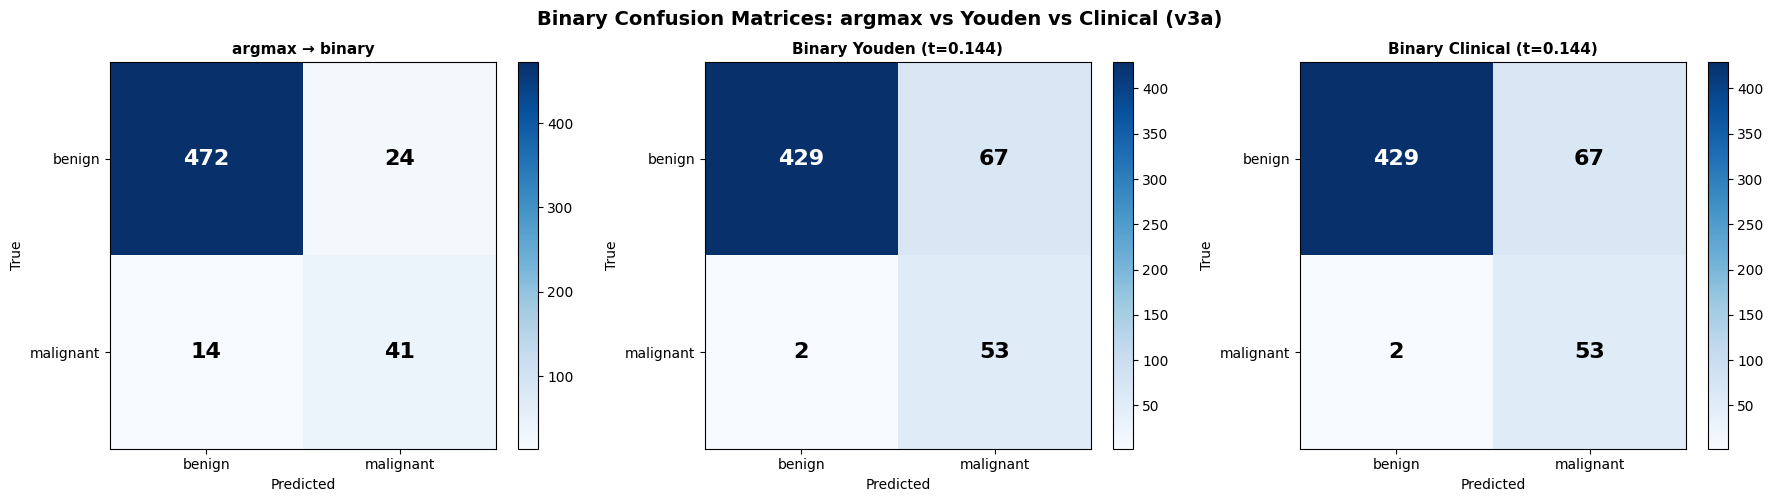

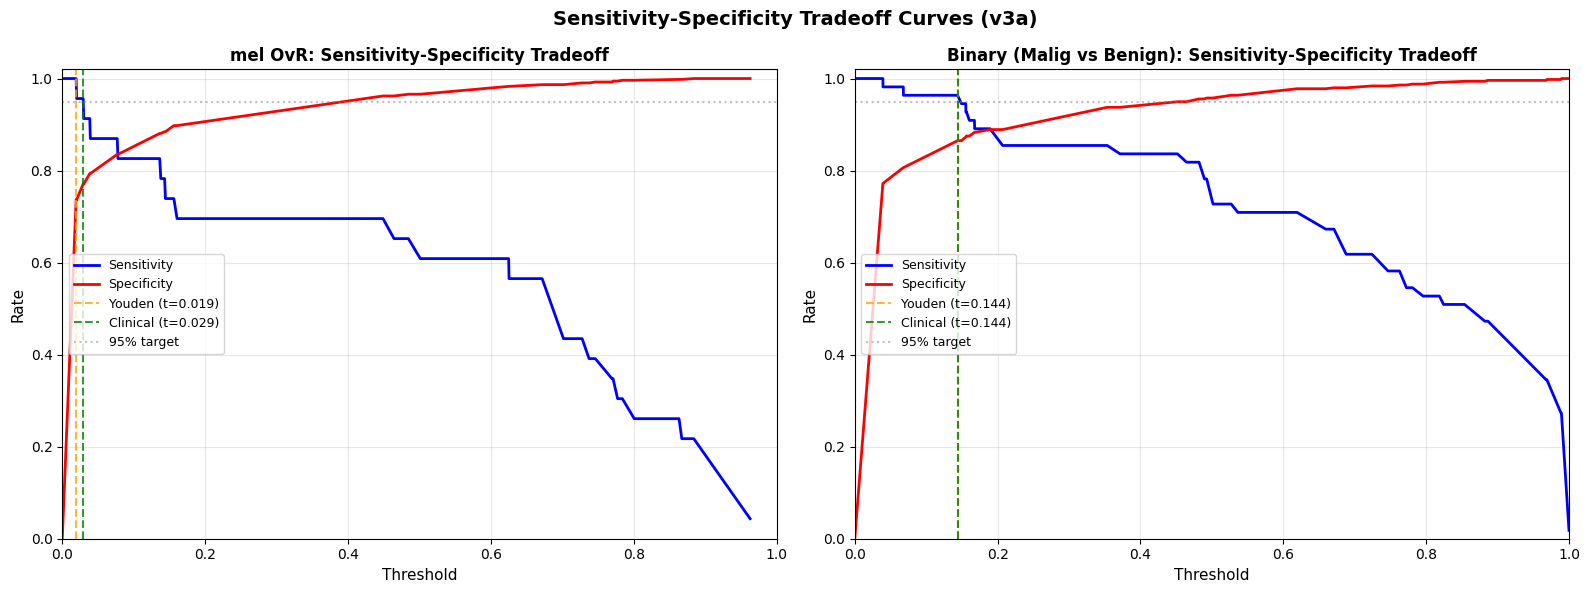


POST-HOC OPTIMIZATION SUMMARY (v3a)

Model: densenet_v3a
ROC-AUC macro: 0.9821 (invariant to post-hoc)
mel ROC-AUC:   0.9410
Binary AUC:    0.9683

--- 7-class mel detection ---
  argmax:        recall=0.652, F1=0.526
  Youden thresh: recall=0.652, F1=0.462

--- Binary malignant detection ---
  Youden:   sens=0.964, spec=0.865, F1=0.606
  Clinical: sens=0.964, spec=0.865, F1=0.606

--- Key insight ---
  mel recall (argmax) is limited by implicit equal thresholds on imbalanced data.
  Post-hoc threshold optimization and binary aggregation recover performance
  without retraining, demonstrating that the model's discriminative ability
  (ROC-AUC) was already strong — the issue was the decision rule, not the model.

  "Statistical optimum and clinical optimum differ.
   Which to choose depends on the operational context."

Saved: posthoc_thresholds_v3a.json


In [8]:
# ============================================================
# Cell 4: A-8 — 比較表（argmax vs 閾値最適化 vs 二値集約）
# ============================================================
"""
A-8: 同じモデルから3つの推論方法で結果を比較
  1. argmax（ベースライン）: 7クラス中最大を選択
  2. 閾値最適化 (Youden): 各クラスOvR最適閾値
  3. 二値集約 (Youden): malignant/benign に集約
  4. 二値集約 (Clinical): 感度≧95%
"""

print("=" * 70)
print("A-8: Comparison — argmax vs Threshold vs Binary")
print("=" * 70)

# --- 8-a: 各手法の予測を生成 ---

# 1. argmax
y_pred_argmax = all_probs.argmax(axis=1)

# 2. Youden閾値（Cell 2で計算済み: y_pred_youden）

# 3. 二値集約（Cell 3で計算済み）
# ただし二値は7クラスの指標と直接比較できないため、
# 「元の7クラスラベルに対する二値判定」と「二値ラベルに対する二値判定」の両方を出す

# --- 8-b: 7クラス指標の比較 ---
def compute_7class_metrics(y_true, y_pred, probs, class_names):
    """7クラスの主要指標を計算"""
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)), zero_division=0
    )
    mel_idx = class_names.index('mel')

    # ROC-AUCはモデルの確率に依存するので全手法で同一（変わるのはrecall/F1）
    return {
        'accuracy': (y_true == y_pred).mean(),
        'macro_f1': f1.mean(),
        'mel_recall': rec[mel_idx],
        'mel_precision': prec[mel_idx],
        'mel_f1': f1[mel_idx],
    }


def compute_binary_metrics(y_true_bin, y_pred_bin, p_malignant_scores):
    """二値の主要指標を計算"""
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true_bin, y_pred_bin, labels=[0, 1], zero_division=0
    )
    binary_auc = roc_auc_score(y_true_bin, p_malignant_scores)
    return {
        'binary_auc': binary_auc,
        'malignant_sensitivity': rec[1],
        'malignant_specificity': rec[0],  # benign recall = malignant specificity
        'malignant_precision': prec[1],
        'malignant_f1': f1[1],
    }


# 7クラスベース指標
metrics_argmax = compute_7class_metrics(y_true, y_pred_argmax, all_probs, CLASS_NAMES)
metrics_youden = compute_7class_metrics(y_true, y_pred_youden, all_probs, CLASS_NAMES)

# 二値ベース指標
metrics_bin_youden = compute_binary_metrics(y_true_binary, y_pred_binary_youden, p_malignant)
metrics_bin_clinical = compute_binary_metrics(y_true_binary, y_pred_binary_clinical, p_malignant)

# --- 8-c: 統合比較表 ---
# ROC-AUC macroはモデル不変（post-hocでは変わらない）
roc_auc_macro = roc_auc_score(y_true_onehot, all_probs, multi_class='ovr', average='macro')
mel_roc_auc = roc_data['mel']['auc']

print(f"\nModel: {NB_NAME}")
print(f"ROC-AUC macro: {roc_auc_macro:.4f} (model property, invariant to post-hoc)")
print(f"mel ROC-AUC:   {mel_roc_auc:.4f}")

comparison_data = {
    'Method': [
        '1. argmax (baseline)',
        '2. Youden threshold (7-class)',
        '3. Binary Youden',
        '4. Binary Clinical (sens≥95%)',
    ],
    'Accuracy / -': [
        f"{metrics_argmax['accuracy']:.3f}",
        f"{metrics_youden['accuracy']:.3f}",
        '-',
        '-',
    ],
    'Macro F1 / -': [
        f"{metrics_argmax['macro_f1']:.3f}",
        f"{metrics_youden['macro_f1']:.3f}",
        '-',
        '-',
    ],
    'mel Recall / Malig Sens': [
        f"{metrics_argmax['mel_recall']:.3f}",
        f"{metrics_youden['mel_recall']:.3f}",
        f"{metrics_bin_youden['malignant_sensitivity']:.3f}",
        f"{metrics_bin_clinical['malignant_sensitivity']:.3f}",
    ],
    'mel Precision / Malig Prec': [
        f"{metrics_argmax['mel_precision']:.3f}",
        f"{metrics_youden['mel_precision']:.3f}",
        f"{metrics_bin_youden['malignant_precision']:.3f}",
        f"{metrics_bin_clinical['malignant_precision']:.3f}",
    ],
    'mel F1 / Malig F1': [
        f"{metrics_argmax['mel_f1']:.3f}",
        f"{metrics_youden['mel_f1']:.3f}",
        f"{metrics_bin_youden['malignant_f1']:.3f}",
        f"{metrics_bin_clinical['malignant_f1']:.3f}",
    ],
    'Binary AUC': [
        '-',
        '-',
        f"{metrics_bin_youden['binary_auc']:.4f}",
        f"{metrics_bin_clinical['binary_auc']:.4f}",
    ],
    'Specificity': [
        '-',
        '-',
        f"{metrics_bin_youden['malignant_specificity']:.3f}",
        f"{metrics_bin_clinical['malignant_specificity']:.3f}",
    ],
}

df_comparison = pd.DataFrame(comparison_data)
print(f"\n{'='*100}")
print("COMPARISON TABLE: argmax vs Threshold Optimization vs Binary Aggregation")
print(f"{'='*100}")
print(df_comparison.to_string(index=False))
print(f"{'='*100}")

# --- 8-d: 二値 Confusion Matrix の可視化 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# argmax → 二値に変換して比較
y_pred_argmax_binary = np.isin(y_pred_argmax, MALIGNANT_INDICES).astype(int)

cms = [
    ('argmax → binary', y_pred_argmax_binary),
    (f'Binary Youden (t={binary_threshold_youden:.3f})', y_pred_binary_youden),
    (f'Binary Clinical (t={binary_threshold_clinical:.3f})', y_pred_binary_clinical),
]

for ax, (title, y_pred_bin) in zip(axes, cms):
    cm = confusion_matrix(y_true_binary, y_pred_bin)
    im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(BINARY_NAMES)
    ax.set_yticklabels(BINARY_NAMES)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

    # 数値を表示
    for row in range(2):
        for col in range(2):
            color = 'white' if cm[row, col] > cm.max() / 2 else 'black'
            ax.text(col, row, str(cm[row, col]), ha='center', va='center',
                    fontsize=16, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f"Binary Confusion Matrices: argmax vs Youden vs Clinical ({NB_NAME})",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_a8_binary_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


# --- 8-e: mel感度-特異度トレードオフ曲線 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左: mel OvR のトレードオフ
ax = axes[0]
mel_fpr = roc_data['mel']['fpr']
mel_tpr = roc_data['mel']['tpr']
mel_thresholds = roc_data['mel']['thresholds']
mel_spec = 1 - mel_fpr

ax.plot(mel_thresholds, mel_tpr, 'b-', linewidth=2, label='Sensitivity')
ax.plot(mel_thresholds, mel_spec, 'r-', linewidth=2, label='Specificity')

youden_t = thresholds_youden['mel']['threshold']
clinical_t = thresholds_clinical['mel']['threshold']
ax.axvline(x=youden_t, color='orange', linestyle='--', alpha=0.8,
           label=f"Youden (t={youden_t:.3f})")
ax.axvline(x=clinical_t, color='green', linestyle='--', alpha=0.8,
           label=f"Clinical (t={clinical_t:.3f})")
ax.axhline(y=0.95, color='gray', linestyle=':', alpha=0.5, label='95% target')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Rate', fontsize=11)
ax.set_title('mel OvR: Sensitivity-Specificity Tradeoff', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='center left')
ax.grid(True, alpha=0.3)

# 右: 二値のトレードオフ
ax = axes[1]
bin_spec = 1 - fpr_bin

ax.plot(thresholds_bin, tpr_bin, 'b-', linewidth=2, label='Sensitivity')
ax.plot(thresholds_bin, bin_spec, 'r-', linewidth=2, label='Specificity')

ax.axvline(x=binary_threshold_youden, color='orange', linestyle='--', alpha=0.8,
           label=f"Youden (t={binary_threshold_youden:.3f})")
ax.axvline(x=binary_threshold_clinical, color='green', linestyle='--', alpha=0.8,
           label=f"Clinical (t={binary_threshold_clinical:.3f})")
ax.axhline(y=0.95, color='gray', linestyle=':', alpha=0.5, label='95% target')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Rate', fontsize=11)
ax.set_title('Binary (Malig vs Benign): Sensitivity-Specificity Tradeoff', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='center left')
ax.grid(True, alpha=0.3)

plt.suptitle(f"Sensitivity-Specificity Tradeoff Curves ({NB_NAME})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_a8_tradeoff_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# --- 8-f: 最終サマリー ---
print("\n" + "=" * 70)
print(f"POST-HOC OPTIMIZATION SUMMARY ({NB_NAME})")
print("=" * 70)

print(f"""
Model: densenet_{NB_NAME}
ROC-AUC macro: {roc_auc_macro:.4f} (invariant to post-hoc)
mel ROC-AUC:   {mel_roc_auc:.4f}
Binary AUC:    {roc_auc_binary:.4f}

--- 7-class mel detection ---
  argmax:        recall={metrics_argmax['mel_recall']:.3f}, F1={metrics_argmax['mel_f1']:.3f}
  Youden thresh: recall={metrics_youden['mel_recall']:.3f}, F1={metrics_youden['mel_f1']:.3f}

--- Binary malignant detection ---
  Youden:   sens={metrics_bin_youden['malignant_sensitivity']:.3f}, spec={metrics_bin_youden['malignant_specificity']:.3f}, F1={metrics_bin_youden['malignant_f1']:.3f}
  Clinical: sens={metrics_bin_clinical['malignant_sensitivity']:.3f}, spec={metrics_bin_clinical['malignant_specificity']:.3f}, F1={metrics_bin_clinical['malignant_f1']:.3f}

--- Key insight ---
  mel recall (argmax) is limited by implicit equal thresholds on imbalanced data.
  Post-hoc threshold optimization and binary aggregation recover performance
  without retraining, demonstrating that the model's discriminative ability
  (ROC-AUC) was already strong — the issue was the decision rule, not the model.

  "Statistical optimum and clinical optimum differ.
   Which to choose depends on the operational context."
""")

# --- 8-g: 閾値をJSONで保存（推論APIで使用） ---
import json

thresholds_export = {
    'model': f'densenet_{NB_NAME}',
    'roc_auc_macro': float(roc_auc_macro),
    'mel_roc_auc': float(mel_roc_auc),
    'binary_roc_auc': float(roc_auc_binary),
    'class_names': CLASS_NAMES,
    'malignant_classes': [CLASS_NAMES[i] for i in MALIGNANT_INDICES],
    'benign_classes': [CLASS_NAMES[i] for i in BENIGN_INDICES],
    'youden_thresholds_7class': {
        cls: {
            'threshold': float(thresholds_youden[cls]['threshold']),
            'sensitivity': float(thresholds_youden[cls]['sensitivity']),
            'specificity': float(thresholds_youden[cls]['specificity']),
        }
        for cls in CLASS_NAMES
    },
    'clinical_threshold_mel': {
        'threshold': float(thresholds_clinical['mel']['threshold']),
        'sensitivity': float(thresholds_clinical['mel']['sensitivity']),
        'specificity': float(thresholds_clinical['mel']['specificity']),
    },
    'binary_youden': {
        'threshold': float(binary_threshold_youden),
        'sensitivity': float(binary_sens_youden),
        'specificity': float(binary_spec_youden),
    },
    'binary_clinical': {
        'threshold': float(binary_threshold_clinical),
        'sensitivity': float(binary_sens_clinical),
        'specificity': float(binary_spec_clinical),
    },
}

with open(RESULTS_DIR / f'posthoc_thresholds_{NB_NAME}.json', 'w') as f:
    json.dump(thresholds_export, f, indent=2)
print(f"Saved: posthoc_thresholds_{NB_NAME}.json")

## 4. Test上での最終メトリクス報告

val上で決定した閾値をtest上で適用し、最終報告用メトリクスを算出する。
test npzはrawなので、ここでTを適用してからメトリクス計算。


In [9]:
# ============================================================
# test npzロード（raw）→ その場でTS適用 → 閾値適用 → 最終メトリクス
# ============================================================
TEST_NPZ_PATH = Path('../results/models/v3a_test_predictions.npz')
_test_data = np.load(TEST_NPZ_PATH)
test_logits  = _test_data['all_logits']  # raw logits
test_y_true  = _test_data['y_true']
N_test = len(test_y_true)
print(f'Loaded test npz: {TEST_NPZ_PATH} (N={N_test})')
print(f'Class dist: {dict(zip(CLASS_NAMES, np.bincount(test_y_true, minlength=NUM_CLASSES)))}')

# TS適用（メモリ上のみ）
test_probs = apply_temperature(test_logits, T)
print(f'TS applied on the fly (T={T:.4f})')

# --- 7クラス評価 ---
test_y_true_onehot = np.eye(NUM_CLASSES)[test_y_true]

# argmax
test_pred_argmax = test_probs.argmax(axis=1)
test_metrics_argmax = compute_7class_metrics(test_y_true, test_pred_argmax, test_probs, CLASS_NAMES)

# Youden閾値（valで決定した閾値をtestに適用）
test_pred_youden, test_fb_youden = predict_with_thresholds(test_probs, thresholds_youden, CLASS_NAMES)
test_metrics_youden = compute_7class_metrics(test_y_true, test_pred_youden, test_probs, CLASS_NAMES)

# ROC-AUC (test)
test_roc_auc_macro = roc_auc_score(test_y_true_onehot, test_probs, multi_class='ovr', average='macro')
test_mel_auc = roc_auc_score(test_y_true_onehot[:, MEL_IDX], test_probs[:, MEL_IDX])

# --- 二値評価 ---
test_p_malignant = test_probs[:, MALIGNANT_INDICES].sum(axis=1)
test_y_true_binary = np.isin(test_y_true, MALIGNANT_INDICES).astype(int)
test_binary_auc = roc_auc_score(test_y_true_binary, test_p_malignant)

# Binary Youden（valで決定した閾値をtestに適用）
test_pred_bin_youden = (test_p_malignant >= binary_threshold_youden).astype(int)
test_metrics_bin_youden = compute_binary_metrics(test_y_true_binary, test_pred_bin_youden, test_p_malignant)

# Binary Clinical（valで決定した閾値をtestに適用）
test_pred_bin_clinical = (test_p_malignant >= binary_threshold_clinical).astype(int)
test_metrics_bin_clinical = compute_binary_metrics(test_y_true_binary, test_pred_bin_clinical, test_p_malignant)

# --- 表示 ---
print(f"\n{'=' * 70}")
print(f"TEST SET FINAL METRICS ({NB_NAME})")
print(f"{'=' * 70}")
print(f"ROC-AUC macro: {test_roc_auc_macro:.4f}")
print(f"mel ROC-AUC:   {test_mel_auc:.4f}")
print(f"Binary AUC:    {test_binary_auc:.4f}")
print(f"\n--- 7-class ---")
print(f"  argmax:  mel recall={test_metrics_argmax['mel_recall']:.3f}, mel F1={test_metrics_argmax['mel_f1']:.3f}, macro F1={test_metrics_argmax['macro_f1']:.3f}")
print(f"  Youden:  mel recall={test_metrics_youden['mel_recall']:.3f}, mel F1={test_metrics_youden['mel_f1']:.3f}, macro F1={test_metrics_youden['macro_f1']:.3f}")
print(f"\n--- Binary ---")
print(f"  Youden:   sens={test_metrics_bin_youden['malignant_sensitivity']:.3f}, spec={test_metrics_bin_youden['malignant_specificity']:.3f}, F1={test_metrics_bin_youden['malignant_f1']:.3f}")
print(f"  Clinical: sens={test_metrics_bin_clinical['malignant_sensitivity']:.3f}, spec={test_metrics_bin_clinical['malignant_specificity']:.3f}, F1={test_metrics_bin_clinical['malignant_f1']:.3f}")

print(f"\n--- Test Classification Report (argmax) ---")
print(classification_report(test_y_true, test_pred_argmax, target_names=CLASS_NAMES, digits=3))


Loaded test npz: ../results/models/v3a_test_predictions.npz (N=552)
Class dist: {'akiec': np.int64(15), 'bcc': np.int64(18), 'bkl': np.int64(44), 'df': np.int64(4), 'mel': np.int64(23), 'nv': np.int64(442), 'vasc': np.int64(6)}
TS applied on the fly (T=1.4478)

TEST SET FINAL METRICS (v3a)
ROC-AUC macro: 0.9781
mel ROC-AUC:   0.9328
Binary AUC:    0.9615

--- 7-class ---
  argmax:  mel recall=0.565, mel F1=0.510, macro F1=0.772
  Youden:  mel recall=0.609, mel F1=0.438, macro F1=0.731

--- Binary ---
  Youden:   sens=0.875, spec=0.885, F1=0.605
  Clinical: sens=0.875, spec=0.885, F1=0.605

--- Test Classification Report (argmax) ---
              precision    recall  f1-score   support

       akiec      0.750     0.600     0.667        15
         bcc      0.789     0.833     0.811        18
         bkl      0.640     0.727     0.681        44
          df      1.000     0.750     0.857         4
         mel      0.464     0.565     0.510        23
          nv      0.975     0.959 

## 5. 実験ログ


In [12]:
# ============================================================
# 実験ログ出力（docs/04_実験ログ.md に追記）
# ============================================================
from datetime import datetime

lines = [
    '',
    f'## v5: DenseNet v3a — Post-hoc 閾値最適化・二値集約',
    f'- **日付**: {datetime.now().strftime("%Y-%m-%d")}',
    f'- **対象モデル**: densenet_v3a',
    f'- **入力**: v3a_val/test_predictions.npz (raw) + temperature_v3a.json (T={T:.4f})',
    f'- **閾値最適化**: valのみ。testは報告のみ。npzは書き換えない',
    '',
    '### Val上の閾値最適化結果',
    f'- mel Youden: 閾値={thresholds_youden["mel"]["threshold"]:.4f}, 感度={thresholds_youden["mel"]["sensitivity"]:.4f}',
    f'- mel Clinical (≧95%): 閾値={thresholds_clinical["mel"]["threshold"]:.4f}, 感度={thresholds_clinical["mel"]["sensitivity"]:.4f}',
    f'- Binary Youden:   閾値={binary_threshold_youden:.4f}, 感度={metrics_bin_youden["malignant_sensitivity"]:.3f}',
    f'- Binary Clinical: 閾値={binary_threshold_clinical:.4f}, 感度={metrics_bin_clinical["malignant_sensitivity"]:.3f}',
    '',
    '### A-6: 閾値最適化（7クラス OvR、val）',
    '',
    '| クラス | 閾値 (Youden) | 感度 | 特異度 | AUC (OvR) |',
    '| ------ | ------------- | ---- | ------ | --------- |',
]
for cls_name in CLASS_NAMES:
    y = thresholds_youden[cls_name]
    lines.append(f'| {cls_name} | {y["threshold"]:.4f} | {y["sensitivity"]:.4f} | {y["specificity"]:.4f} | {roc_data[cls_name]["auc"]:.4f} |')

val_mel_auc = mel_roc_auc
val_binary_auc = metrics_bin_youden['binary_auc']
lines += [
    '',
    f'**臨床閾値 (mel感度≧95%)**: 閾値={thresholds_clinical["mel"]["threshold"]:.4f}, 感度={thresholds_clinical["mel"]["sensitivity"]:.4f}, 特異度={thresholds_clinical["mel"]["specificity"]:.4f}',
    '',
    '### A-7: 二値集約 (mel+bcc+akiec、val)',
    '',
    f'- **mel OvR AUC**: {val_mel_auc:.4f}',
    f'- **Binary AUC**: {val_binary_auc:.4f}  (Δ={val_binary_auc - val_mel_auc:+.4f})',
    '',
    '| 手法 | 閾値 | 感度 | 特異度 | Precision | F1 |',
    '| ---- | ---- | ---- | ------ | --------- | -- |',
    f'| Binary Youden   | {binary_threshold_youden:.4f} | {metrics_bin_youden["malignant_sensitivity"]:.3f} | {metrics_bin_youden["malignant_specificity"]:.3f} | {metrics_bin_youden["malignant_precision"]:.3f} | {metrics_bin_youden["malignant_f1"]:.3f} |',
    f'| Binary Clinical  | {binary_threshold_clinical:.4f} | {metrics_bin_clinical["malignant_sensitivity"]:.3f} | {metrics_bin_clinical["malignant_specificity"]:.3f} | {metrics_bin_clinical["malignant_precision"]:.3f} | {metrics_bin_clinical["malignant_f1"]:.3f} |',
    '',
    '### Test上の最終報告メトリクス ★',
    f'- **ROC-AUC macro**: {test_roc_auc_macro:.4f}',
    f'- **mel ROC-AUC**: {test_mel_auc:.4f}',
    f'- **Binary AUC**: {test_binary_auc:.4f}',
    '',
    '| 手法 | mel/malig Recall | mel/malig Prec | mel/malig F1 | Macro F1 | Binary AUC |',
    '| ---- | ---------------- | -------------- | ------------ | -------- | ---------- |',
    f'| argmax           | {test_metrics_argmax["mel_recall"]:.3f} | {test_metrics_argmax["mel_precision"]:.3f} | {test_metrics_argmax["mel_f1"]:.3f} | {test_metrics_argmax["macro_f1"]:.3f} | - |',
    f'| Youden threshold | {test_metrics_youden["mel_recall"]:.3f} | {test_metrics_youden["mel_precision"]:.3f} | {test_metrics_youden["mel_f1"]:.3f} | {test_metrics_youden["macro_f1"]:.3f} | - |',
    f'| Binary Youden    | {test_metrics_bin_youden["malignant_sensitivity"]:.3f} | {test_metrics_bin_youden["malignant_precision"]:.3f} | {test_metrics_bin_youden["malignant_f1"]:.3f} | - | {test_binary_auc:.4f} |',
    f'| Binary Clinical  | {test_metrics_bin_clinical["malignant_sensitivity"]:.3f} | {test_metrics_bin_clinical["malignant_precision"]:.3f} | {test_metrics_bin_clinical["malignant_f1"]:.3f} | - | {test_binary_auc:.4f} |',
    '',
    '### 成果物',
    f'- results/v5_ph/posthoc_thresholds_{NB_NAME}.json',
    f'- results/v5_ph/fig_a6, a7, a8_*.png',
    '',
    '### 判断・メモ',
    '- 閾値はvalで最適化、testは報告のみ（情報リークなし）',
    '- npzは常にraw。TSはjsonからTを読みその場で適用',
    '- デプロイ: Binary Clinical閾値を採用（mel感度≧95%優先）',
    '',
]
print('\n'.join(lines))
print('\n↑ docs/04_実験ログ.md に追記してください')


## v5: DenseNet v3a — Post-hoc 閾値最適化・二値集約
- **日付**: 2026-03-11
- **対象モデル**: densenet_v3a
- **入力**: v3a_val/test_predictions.npz (raw) + temperature_v3a.json (T=1.4478)
- **閾値最適化**: valのみ。testは報告のみ。npzは書き換えない

### Val上の閾値最適化結果
- mel Youden: 閾値=0.0194, 感度=1.0000
- mel Clinical (≧95%): 閾値=0.0292, 感度=0.9565
- Binary Youden:   閾値=0.1439, 感度=0.964
- Binary Clinical: 閾値=0.1439, 感度=0.964

### A-6: 閾値最適化（7クラス OvR、val）

| クラス | 閾値 (Youden) | 感度 | 特異度 | AUC (OvR) |
| ------ | ------------- | ---- | ------ | --------- |
| akiec | 0.0161 | 0.9333 | 0.9534 | 0.9752 |
| bcc | 0.0252 | 1.0000 | 0.9625 | 0.9957 |
| bkl | 0.1066 | 0.9318 | 0.9231 | 0.9738 |
| df | 0.2188 | 1.0000 | 0.9963 | 0.9982 |
| mel | 0.0194 | 1.0000 | 0.7367 | 0.9410 |
| nv | 0.6629 | 0.9342 | 0.9727 | 0.9920 |
| vasc | 0.0483 | 1.0000 | 0.9926 | 0.9989 |

**臨床閾値 (mel感度≧95%)**: 閾値=0.0292, 感度=0.9565, 特異度=0.7708

### A-7: 二値集約 (mel+bcc+akiec、val)

- **mel OvR AUC**: 0.9410
- **Binary AUC**: 0.9683  (Δ=+0.0273)

| 手法 | 閾値 | 感度 | 特異